# Map & Path Visualization
Đầu vào: file obstacle grid `.txt`, radiation grid `.txt`, và path dạng list của tuple `(row, col)`.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pathlib import Path

# ─────────────────────────────────────────
# CẤU HÌNH ĐẦU VÀO  (chỉnh tại đây)
# ─────────────────────────────────────────
OBSTACLE_FILE  = "data/scenario7/scenario7_grid.txt"
RADIATION_FILE = "data/scenario7/radiation_grid.txt"

# ─────────────────────────────────────────
# ĐỌC PATH TỪ route_summary.json (tuỳ chọn)
# ─────────────────────────────────────────
import json

JSON_FILE = "results/scenario7/paths/route_summary.json"

with open(JSON_FILE) as f:
    data = json.load(f)

path_from_json = [tuple(p) for p in data["full_path"]]
# print(f"Path từ JSON: {len(path_from_json)} steps")
# print("5 bước đầu:", path_from_json[:5])
# print("5 bước cuối:", path_from_json[-5:])

# PATH = [
#     (1, 4), (2, 4), (3, 3), (4, 2), (4, 1), (4, 2), (5, 3),
#     (6, 4), (6, 5), (6, 6), (6, 7), (6, 8), (7, 9), (8, 9),
#     (9, 9), (8, 9), (7, 9), (6, 8), (6, 7), (6, 6), (5, 5),
#     (4, 5), (3, 5), (2, 4), (1, 4)
# ]

PATH = path_from_json

SAVE_PATH = None          # None = chỉ hiển thị; đặt đường dẫn .png để lưu
SHOW_GRID_LINES = True    # kẻ ô lưới
RI_MAX = 8.0              # ngưỡng phân loại high risk

In [8]:
# ─────────────────────────────────────────
# ĐỌC FILE
# ─────────────────────────────────────────
def load_txt(path, dtype=float):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append([dtype(x) for x in line.split()])
    return np.array(rows, dtype=dtype)

obstacle  = load_txt(OBSTACLE_FILE,  dtype=int)
radiation = load_txt(RADIATION_FILE, dtype=float)

assert obstacle.shape == radiation.shape, "Grid size mismatch!"
nrows, ncols = obstacle.shape
print(f"Map size: {nrows} × {ncols}")
print(f"Targets (value 2): {(obstacle == 2).sum()}")
print(f"Obstacles (value 1): {(obstacle == 1).sum()}")
print(f"Radiation max: {radiation.max():.2f}, cells > ri_max: {(radiation > RI_MAX).sum()}")
print(f"Path steps: {len(PATH)}")

Map size: 100 × 100
Targets (value 2): 60
Obstacles (value 1): 861
Radiation max: 10.50, cells > ri_max: 326
Path steps: 821


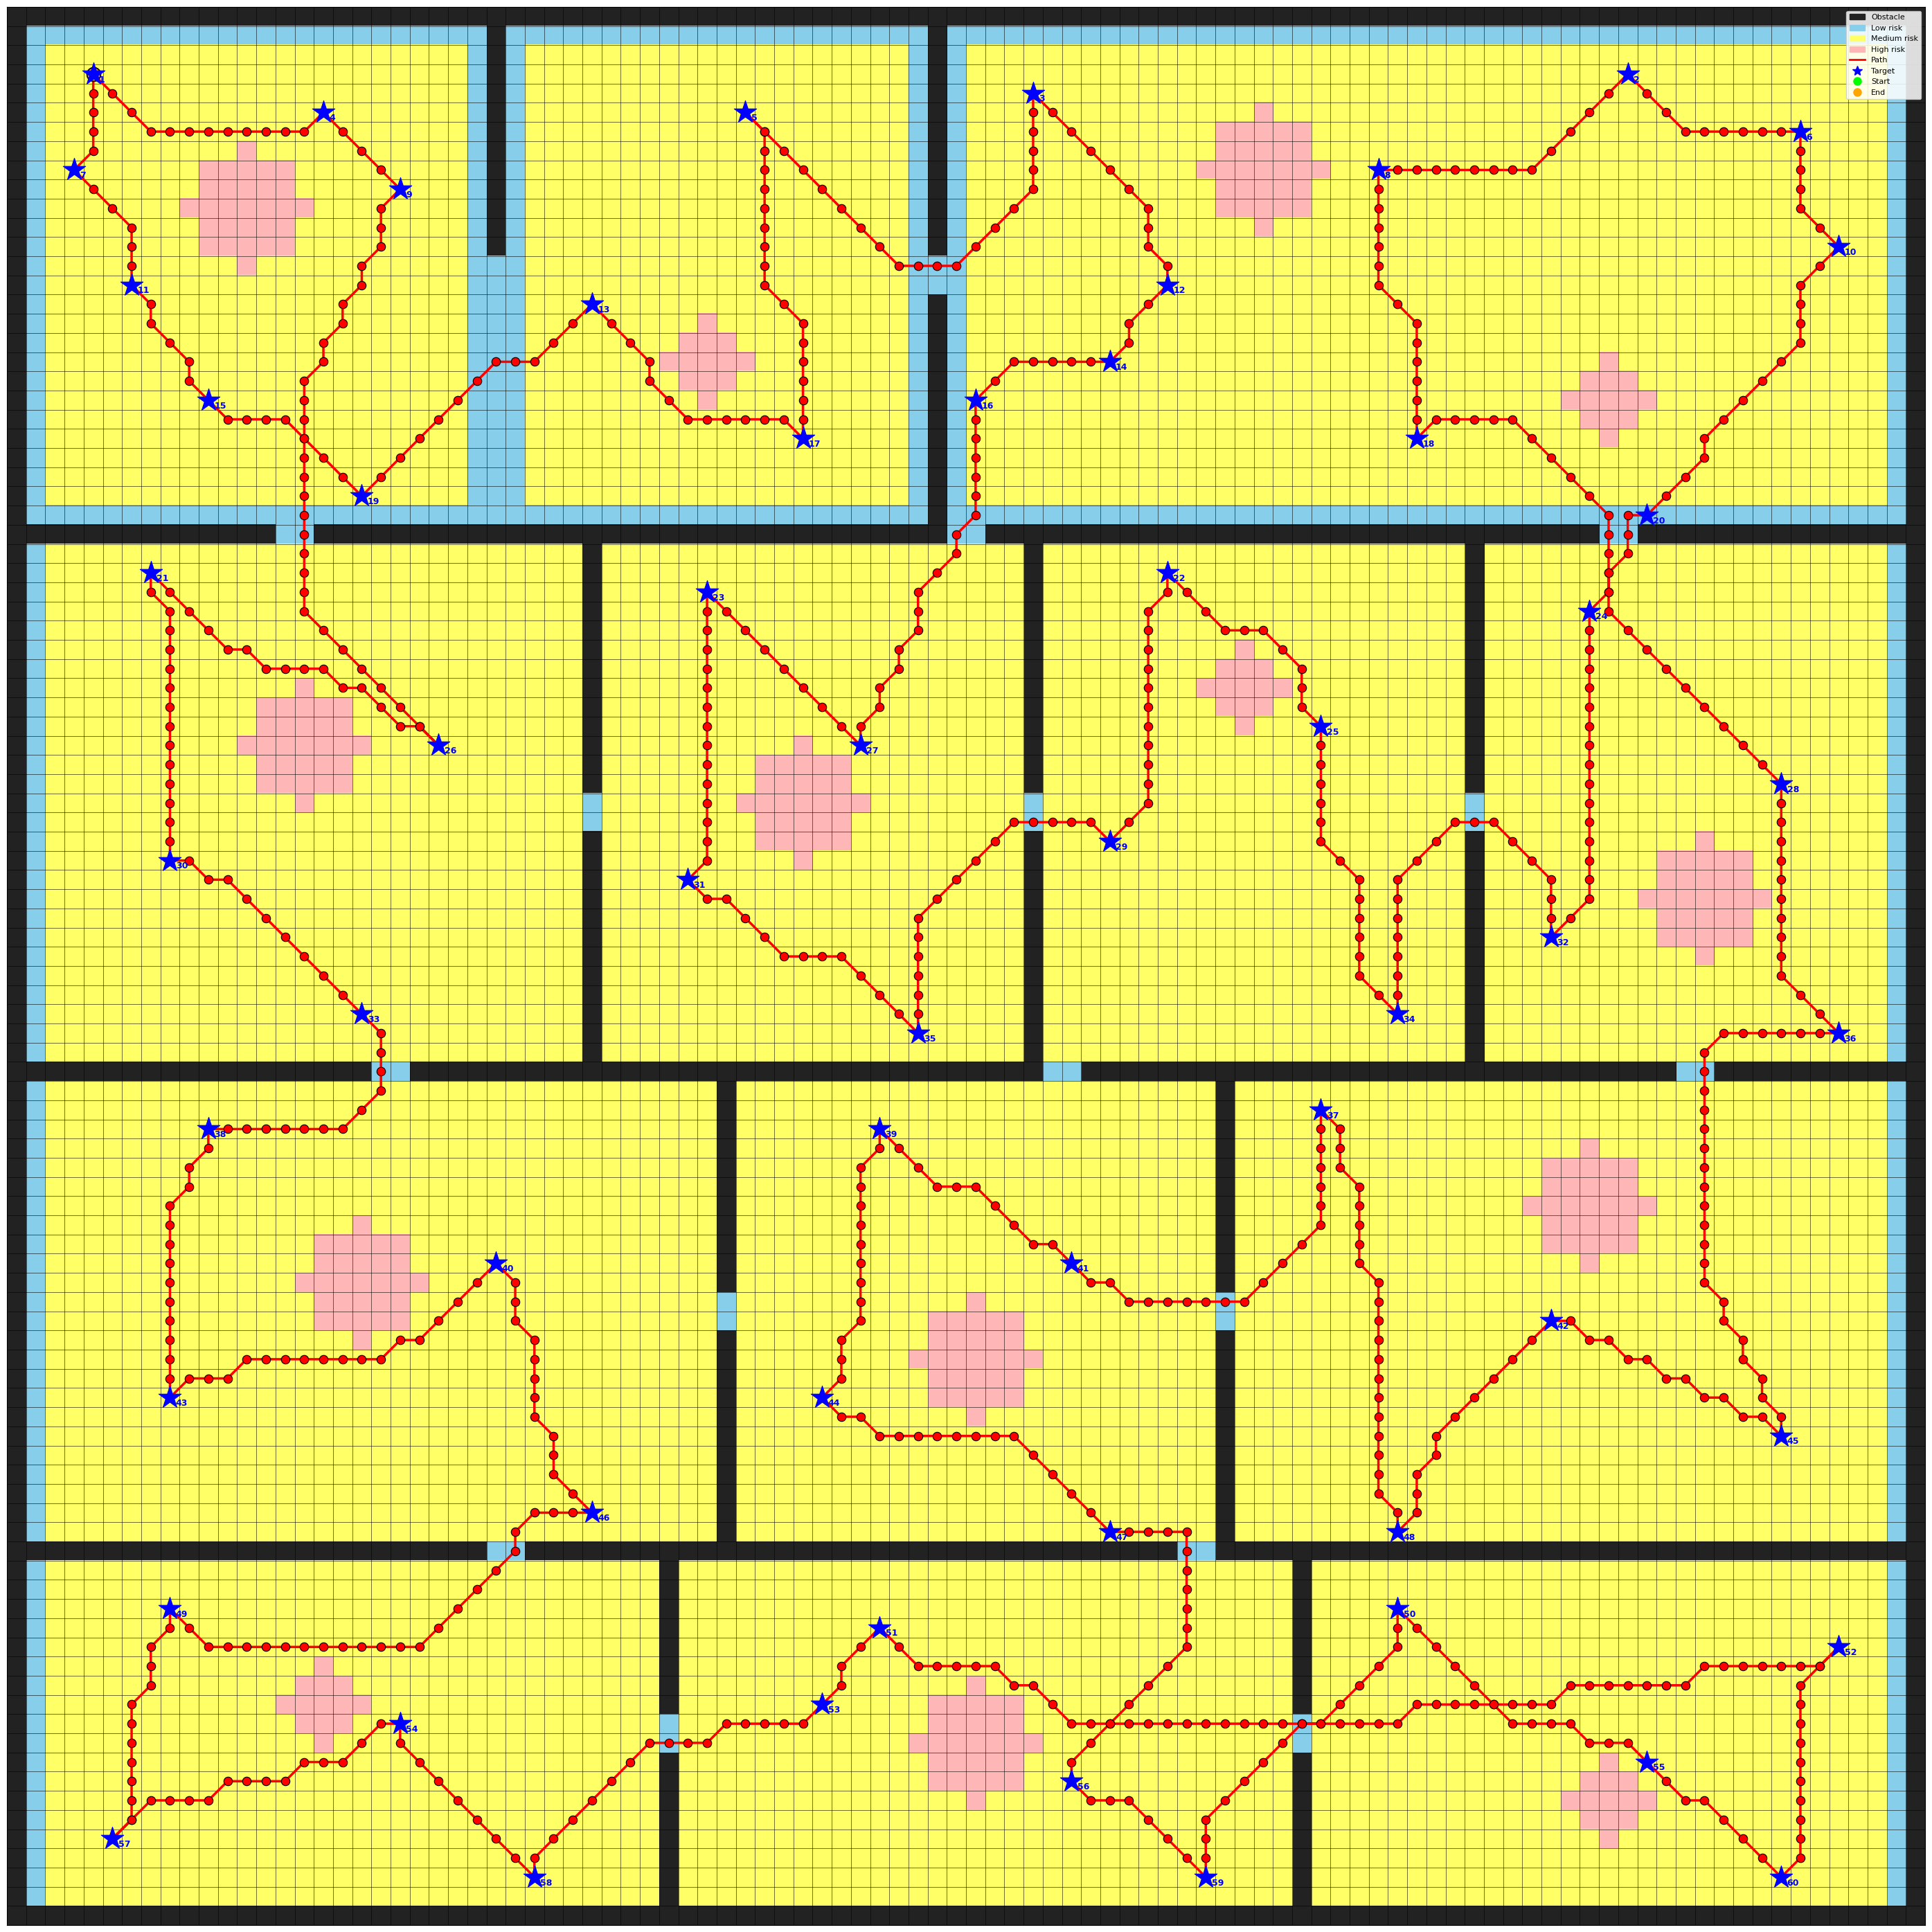

In [9]:
# ─────────────────────────────────────────
# VẼ BẢN ĐỒ + ĐƯỜNG ĐI
# ─────────────────────────────────────────
LOW_THRESH  = 0.5
HIGH_THRESH = RI_MAX

# Phân loại từng ô: 0=obstacle, 1=low, 2=medium, 3=high risk
base = np.ones_like(obstacle, dtype=int)          # default: low risk
base[radiation >= LOW_THRESH]  = 2                # medium risk (vàng)
base[radiation >= HIGH_THRESH] = 3                # high risk  (hồng)
base[obstacle == 1]            = 0                # obstacle   (đen)

cmap = ListedColormap([
    "#222222",  # 0: obstacle
    "#87CEEB",  # 1: low risk  – sky blue
    "#FFFF66",  # 2: med risk  – vàng
    "#FFB6B6",  # 3: high risk – hồng
])

fig_w = max(10, ncols * 0.28)
fig_h = max(8,  nrows * 0.28)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# --- nền bản đồ ---
ax.imshow(base, cmap=cmap, vmin=0, vmax=3,
          origin="upper", interpolation="nearest")

# --- đường đi ---
if PATH:
    xs = [p[1] for p in PATH]
    ys = [p[0] for p in PATH]
    ax.plot(xs, ys, color="red", linewidth=2.5, zorder=4)
    ax.scatter(xs, ys, s=80, c="red", edgecolors="black",
               linewidths=0.8, zorder=5)
    # điểm bắt đầu = xanh lá, điểm kết thúc = cam
    ax.scatter(xs[0],  ys[0],  s=200, c="lime",   edgecolors="black",
               linewidths=1.2, zorder=6, marker="o")
    ax.scatter(xs[-1], ys[-1], s=200, c="orange", edgecolors="black",
               linewidths=1.2, zorder=6, marker="o")

# --- targets (ngôi sao xanh) ---
target_pos = np.argwhere(obstacle == 2)
for idx, (r, c) in enumerate(target_pos, start=1):
    ax.scatter(c, r, marker="*", s=600, c="blue",
               edgecolors="blue", linewidths=0.8, zorder=8)
    ax.text(c + 0.3, r + 0.3, str(idx),
            color="blue", fontsize=9, fontweight="bold",
            ha="left", va="center", zorder=9)

# --- lưới ô ---
if SHOW_GRID_LINES:
    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
    ax.tick_params(which="both", bottom=False, left=False,
                   labelbottom=False, labelleft=False)

ax.set_xlim(-0.5, ncols - 0.5)
ax.set_ylim(nrows - 0.5, -0.5)
ax.set_aspect("equal")

# --- legend ---
legend_items = [
    mpatches.Patch(color="#222222", label="Obstacle"),
    mpatches.Patch(color="#87CEEB", label="Low risk"),
    mpatches.Patch(color="#FFFF66", label="Medium risk"),
    mpatches.Patch(color="#FFB6B6", label="High risk"),
    plt.Line2D([0],[0], color="red",  linewidth=2, label="Path"),
    plt.Line2D([0],[0], marker="*",   color="blue", linestyle="None",
               markersize=10, label="Target"),
    plt.Line2D([0],[0], marker="o",   color="lime", linestyle="None",
               markersize=8, label="Start"),
    plt.Line2D([0],[0], marker="o",   color="orange", linestyle="None",
               markersize=8, label="End"),
]
ax.legend(handles=legend_items, loc="upper right",
          fontsize=8, framealpha=0.85)

fig.tight_layout()

if SAVE_PATH:
    Path(SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_PATH, dpi=150, bbox_inches="tight")
    print(f"Saved: {SAVE_PATH}")

plt.show()

In [10]:
# ─────────────────────────────────────────
# IN PATH RA TEXT
# ─────────────────────────────────────────
print(f"Path ({len(PATH)} steps):")
print(PATH)
print()
print("Từng bước:")
for i, (r, c) in enumerate(PATH):
    cell_type = {
        0: "free",
        1: "obstacle",
        2: "target",
    }.get(obstacle[r, c], "free")
    rad_val = radiation[r, c]
    risk = "high" if rad_val >= RI_MAX else ("med" if rad_val >= 0.5 else "low")
    print(f"  step {i:3d}: ({r:3d}, {c:3d})  cell={cell_type:<8}  radiation={rad_val:.3f}  risk={risk}")

Path (821 steps):
[(3, 4), (4, 4), (5, 4), (6, 4), (7, 4), (8, 3), (9, 4), (10, 5), (11, 6), (12, 6), (13, 6), (14, 6), (15, 7), (16, 7), (17, 8), (18, 9), (19, 9), (20, 10), (21, 11), (21, 12), (21, 13), (21, 14), (22, 15), (23, 16), (24, 17), (25, 18), (24, 19), (23, 20), (22, 21), (21, 22), (20, 23), (19, 24), (18, 25), (18, 26), (18, 27), (17, 28), (16, 29), (15, 30), (16, 31), (17, 32), (18, 33), (19, 33), (20, 34), (21, 35), (21, 36), (21, 37), (21, 38), (21, 39), (21, 40), (22, 41), (21, 41), (20, 41), (19, 41), (18, 41), (17, 41), (16, 41), (15, 40), (14, 39), (13, 39), (12, 39), (11, 39), (10, 39), (9, 39), (8, 39), (7, 39), (6, 39), (5, 38), (6, 39), (7, 40), (8, 41), (9, 42), (10, 43), (11, 44), (12, 45), (13, 46), (13, 47), (13, 48), (13, 49), (12, 50), (11, 51), (10, 52), (9, 53), (8, 53), (7, 53), (6, 53), (5, 53), (4, 53), (5, 54), (6, 55), (7, 56), (8, 57), (9, 58), (10, 59), (11, 59), (12, 59), (13, 60), (14, 60), (15, 59), (16, 58), (17, 58), (18, 57), (18, 56), (18, 

In [11]:
# ─────────────────────────────────────────
# ĐỌC PATH TỪ route_summary.json (tuỳ chọn)
# ─────────────────────────────────────────
import json

JSON_FILE = "results/scenario7/paths/route_summary.json"

with open(JSON_FILE) as f:
    data = json.load(f)

path_from_json = [tuple(p) for p in data["full_path"]]
print(f"Path từ JSON: {len(path_from_json)} steps")
print("5 bước đầu:", path_from_json[:5])
print("5 bước cuối:", path_from_json[-5:])

Path từ JSON: 821 steps
5 bước đầu: [(3, 4), (4, 4), (5, 4), (6, 4), (7, 4)]
5 bước cuối: [(6, 8), (6, 7), (5, 6), (4, 5), (3, 4)]
